# Linearization Methods in Macroeconomics

## Introduction

Macroeconomic models are almost universally nonlinear. Production functions, utility functions, budget constraints, and equilibrium conditions all involve products, ratios, and exponentials of endogenous variables. Solving these models exactly is generally impossible — closed-form solutions exist only in special cases — so economists rely on approximation methods that replace the original nonlinear system with a tractable linear one in the neighborhood of a particular equilibrium.

This notebook develops two related linearization techniques that are workhorses of modern macroeconomics:

1. **Taylor approximation**: the general mathematical tool for approximating a    smooth function by a linear (or higher-order polynomial) function near a    point of interest.
2. **Log-linearization and Uhlig's method**: a specialized application of Taylor approximation that expresses model variables as log-deviations from their steady-state values, producing an approximation that is particularly convenient for multiplicative nonlinearities.

Throughout we emphasize both the mechanics — the step-by-step procedure for applying each method — and the economic interpretation: what does the linear approximation tell us about the behavior of the model near its steady state, and when is it a reliable guide to the model's true dynamics?

## Taylor Approximation

### Functions of One Variable

The Taylor approximation replaces a smooth function $F: \mathbb{R} \to \mathbb{R}$ with a polynomial that behaves similarly to $F$ within a neighborhood of a point $x^*$. The first-order (linear) Taylor approximation around $x^*$ is:

$$F(x^* + \Delta x) \approx F(x^*) + F'(x^*)\Delta x$$

where $\Delta x = x - x^*$ is the perturbation around the approximation point. Geometrically, this replaces the curve $F(x)$ with its **tangent line** at $x^*$. The approximation is exact at $x = x^*$ and becomes less accurate as $|\Delta x|$ grows — the approximation error is of order $O((\Delta x)^2)$.

The quality of the approximation depends on two things: the size of the perturbation $|\Delta x|$ and the curvature of $F$ at $x^*$ (captured by $F''(x^*)$). A highly curved function is poorly approximated by its tangent line even for small perturbations; a nearly linear function is well approximated even for large perturbations.

### Functions of Multiple Variables

For $F: \mathbb{R}^2 \to \mathbb{R}$, the first-order Taylor approximation around $(x^*, y^*)$ is:

$$F(x^* + \Delta x,\, y^* + \Delta y) \approx F(x^*, y^*) + 
\frac{\partial F}{\partial x}(x^*, y^*)\Delta x + 
\frac{\partial F}{\partial y}(x^*, y^*)\Delta y$$

The change in the function value is represented by the **linear map**:

$$F(x^* + \Delta x, y^* + \Delta y) - F(x^*, y^*) \approx 
\begin{pmatrix}\dfrac{\partial F}{\partial x}(x^*,y^*) & 
\dfrac{\partial F}{\partial y}(x^*,y^*)\end{pmatrix}
\begin{pmatrix}\Delta x \\ \Delta y\end{pmatrix}$$

Geometrically this replaces the surface $F(x, y)$ with its **tangent plane** at $(x^*, y^*)$.

### Vector-Valued Functions: The Jacobian

For a vector-valued function $F = (f_1, f_2, \ldots, f_m): \mathbb{R}^n \to \mathbb{R}^m$, the first-order Taylor approximation around $x^*$ is:

$$F(x^* + \Delta x) \approx F(x^*) + J_F(x^*)\,\Delta x$$

where $J_F(x^*)$ is the **Jacobian matrix** of $F$ evaluated at $x^*$:

$$J_F(x^*) = \begin{pmatrix}
\dfrac{\partial f_1}{\partial x_1}(x^*) & \cdots & 
\dfrac{\partial f_1}{\partial x_n}(x^*) \\[8pt]
\vdots & \ddots & \vdots \\[4pt]
\dfrac{\partial f_m}{\partial x_1}(x^*) & \cdots & 
\dfrac{\partial f_m}{\partial x_n}(x^*)
\end{pmatrix}$$

The Jacobian is the multi-dimensional generalization of the derivative: it captures the first-order sensitivity of every output to every input. In macroeconomic applications, $F$ is typically a system of equilibrium conditions, $x^*$ is the steady state, and $J_F(x^*)$ governs the local dynamics of the model around that steady state. The eigenvalues of the Jacobian determine whether the steady state is stable, unstable, or a saddle point — as we saw in the dynamics notebook.

### Numerical Illustration

As an example, consider approximating the exponential function $F(x)=e^x$ and it's inverse $G(x)=\ln x$ about the point $x^*=1$.  We have the first-order Taylor approximations
$$
\begin{align}
F(x^*+\Delta x) &\approx e^{x^*}+e^{x^*}(x-x^*) = e \cdot x \\
G(x^*+\Delta x) &\approx \ln(x^*)+1/x^*(x-x^*) =  x-1
\end{align}
$$

and second-order approximations
$$
\begin{align}
F(x^*+\Delta x) &\approx e^{x^*}+e^{x^*}(x-x^*)+\frac{e^{x^*}}{2}(x-x^*)^2 = e \left( 1 + (x-1) + \frac{(x-1)^2}{2} \right) \\
G(x^*+\Delta x) &\approx \ln(x^*)+1/x^*(x-x^*)-\frac{1}{2{x^*}^2}(x-x^*)^2 = (x-1) - \frac{1}{2}(x-1)^2
\end{align}
$$

The left two panels plot these first- and second-order Taylor approximations for $e^x$ and $\ln x$ around $x^* = 1$. The first-order approximation (tangent line) is exact at $x^*$ and diverges from the true function as $|x - x^*|$ grows. The second-order approximation tracks the function more closely by capturing its curvature. The right panel quantifies the approximation error as a function of perturbation size on a log scale. Hence, first-order approximations are useful for studying small fluctuations around the steady state — which is exactly the business cycle application.

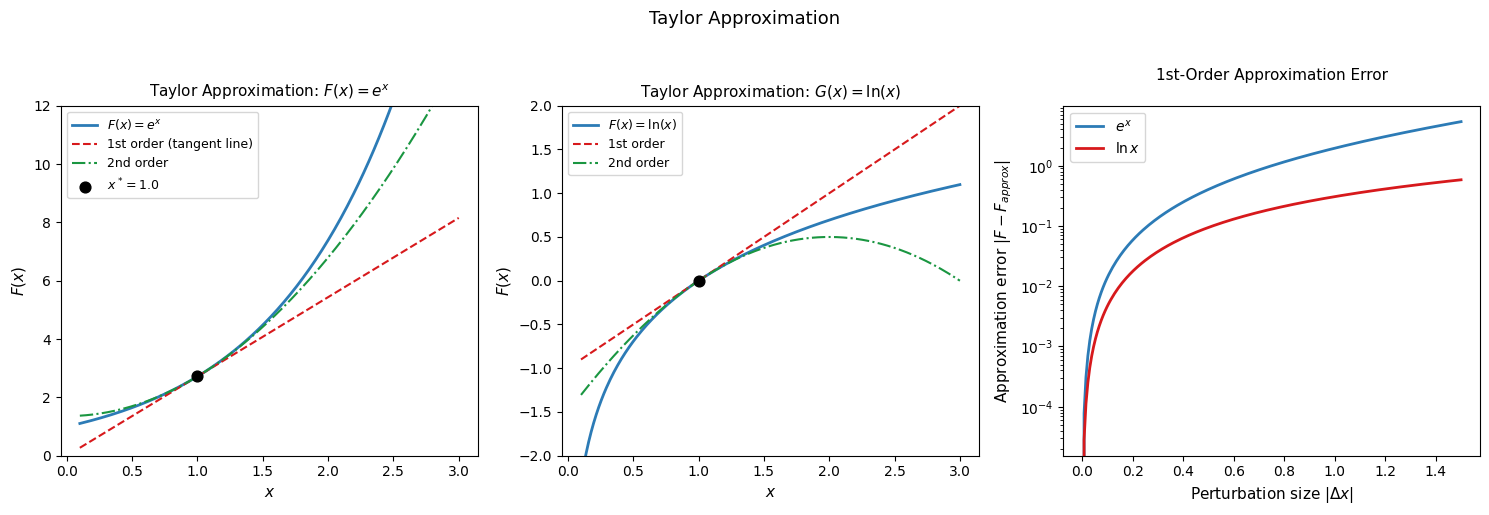

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ──────────────────────────────────────────────
# Panel 1: Taylor approximation for R -> R
# Show tangent line approximation for several functions and expansion points
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

x_grid = np.linspace(0.1, 3, 300)

# Example 1: F(x) = exp(x), expand around x*=1
x_star = 1.0
F      = np.exp
dF     = np.exp   # F'(x) = exp(x)

ax = axes[0]
ax.plot(x_grid, F(x_grid), color="#2c7bb6", lw=2,
        label=r"$F(x) = e^x$")

# Taylor approximations of different orders
ax.plot(x_grid,
        F(x_star) + dF(x_star)*(x_grid - x_star),
        color="#d7191c", lw=1.5, ls="--",
        label=r"1st order (tangent line)")
ax.plot(x_grid,
        F(x_star) + dF(x_star)*(x_grid - x_star)
        + 0.5*F(x_star)*(x_grid - x_star)**2,
        color="#1a9641", lw=1.5, ls="-.",
        label=r"2nd order")
ax.scatter([x_star], [F(x_star)], color="black",
           zorder=5, s=60, label=rf"$x^* = {x_star}$")
ax.set_xlabel("$x$", fontsize=11)
ax.set_ylabel("$F(x)$", fontsize=11)
ax.set_title(r"Taylor Approximation: $F(x) = e^x$",
             fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(0, 12)

# Example 2: F(x) = log(x), expand around x*=1
F2  = np.log
dF2 = lambda x: 1/x
d2F2 = lambda x: -1/x**2

ax = axes[1]
ax.plot(x_grid, F2(x_grid), color="#2c7bb6", lw=2,
        label=r"$F(x) = \ln(x)$")
ax.plot(x_grid,
        F2(x_star) + dF2(x_star)*(x_grid - x_star),
        color="#d7191c", lw=1.5, ls="--",
        label="1st order")
ax.plot(x_grid,
        F2(x_star) + dF2(x_star)*(x_grid - x_star)
        + 0.5*d2F2(x_star)*(x_grid - x_star)**2,
        color="#1a9641", lw=1.5, ls="-.",
        label="2nd order")
ax.scatter([x_star], [F2(x_star)], color="black",
           zorder=5, s=60)
ax.set_xlabel("$x$", fontsize=11)
ax.set_ylabel("$F(x)$", fontsize=11)
ax.set_title(r"Taylor Approximation: $G(x) = \ln(x)$",
             fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(-2, 2)

# Example 3: approximation error as a function
# of perturbation size |Delta x|
ax = axes[2]
delta_grid = np.linspace(0, 1.5, 200)

for F3, dF3, d2F3, label, color in [
    (np.exp,   np.exp,      np.exp,
     r"$e^x$", "#2c7bb6"),
    (np.log,   lambda x: 1/x, lambda x: -1/x**2,
     r"$\ln x$", "#d7191c"),
]:
    true_val   = F3(x_star + delta_grid)
    approx_val = (F3(x_star)
                  + dF3(x_star)*delta_grid)
    error      = np.abs(true_val - approx_val)
    ax.plot(delta_grid, error, color=color,
            lw=2, label=label)

ax.set_xlabel(r"Perturbation size $|\Delta x|$",
              fontsize=11)
ax.set_ylabel("Approximation error $|F - F_{approx}|$",
              fontsize=11)
ax.set_title("1st-Order Approximation Error\n"
             , fontsize=11)
ax.legend(fontsize=10)
ax.set_yscale("log")

fig.suptitle("Taylor Approximation", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Log-Linearization

### Motivation

First-order Taylor approximations applied to a nonlinear model produces a linear approximation in the **levels** of variables. In macroeconomics, a more natural approximation works in **log-deviations** from steady state. There are three reasons for this preference:

1. **Multiplicative nonlinearities become additive.** Many macroeconomic relationships involve products and ratios — $Y = AK^\alpha L^{1-\alpha}$, $pq = wl + rk$, and so on. Taking logs converts multiplication to addition and division to subtraction, dramatically simplifying the algebra.

2. **Log-deviations are interpretable as percentage changes.** If $\tilde{x} \equiv \ln x - \ln x^*$, then $\tilde{x} \approx (x - x^*)/x^*$ for small deviations — the log-deviation is approximately the percentage deviation from steady state. This makes the linearized model's predictions directly comparable to empirical moments expressed as percentage deviations.

3. **Coefficients have elasticity interpretations.** In a log-linearized equation, the coefficient on $\tilde{x}$ in the expression for $\tilde{y}$ is the elasticity of $y$ with respect to $x$ — the percentage change in $y$ per one percent change in $x$. These are among the most economically meaningful objects in applied work.

### The Log-Linearization Procedure

Consider a nonlinear model given by  $F(x) = G(x)/H(x)$. The log-linearization proceeds in two steps.

**Step 1.** Take the logarithm of both sides:

$$\ln F(x) = \ln G(x) - \ln H(x)$$

**Step 2.** Take a first-order Taylor approximation of each term around $x^*$:

$$\ln F(x^*) + \frac{F'(x^*)}{F(x^*)}(x - x^*) \approx 
\ln G(x^*) + \frac{G'(x^*)}{G(x^*)}(x - x^*) - 
\ln H(x^*) - \frac{H'(x^*)}{H(x^*)}(x - x^*)$$

Since the original equation must hold at the steady state, $\ln F(x^*) = 
\ln G(x^*) - \ln H(x^*)$ cancels, leaving:

$$\frac{F'(x^*)}{F(x^*)}(x - x^*) \approx 
\frac{G'(x^*)}{G(x^*)}(x - x^*) - \frac{H'(x^*)}{H(x^*)}(x - x^*)$$

This is the log-linear approximation: a linear equation in the percentage 
deviations of $x$ from its steady-state value.

## Uhlig's Method

### The Algorithm

Harald Uhlig developed a particularly efficient algorithm for log-linearizing 
macroeconomic models that exploits the structure of the approximation to minimize 
the algebra involved. The algorithm has three steps:

**Step 1.** Define log-deviations $\tilde{x} \equiv \ln x - \ln x^*$, and 
rewrite every variable in the model as $x = x^* e^{\tilde{x}}$. Substitute 
throughout.

**Step 2.** Algebraically combine as many exponential terms as possible, 
collecting them into a single expression $e^{(\text{linear combination of } 
\tilde{x}_i)}$.

**Step 3.** Apply the first-order Taylor approximation $e^u \approx 1 + u$ 
for small $u$, where $u$ is the linear combination from Step 2. Since $\tilde{x} 
= 0$ at the steady state by construction, higher-order terms in $\tilde{x}$ are 
discarded.

### Uhlig's Rules

The procedure in Steps 1–3 can be summarized as a set of simple algebraic 
rules that can be applied mechanically:

```{admonition} Uhlig's Rules
:class: important

For log-deviations $\tilde{x} \approx (x - x^*)/x^*$ small:

1. **Exponential approximation**: $e^{\tilde{x} + \alpha\tilde{y}} \approx 
   1 + \tilde{x} + \alpha\tilde{y}$
2. **Product approximation**: $\tilde{x}\tilde{y} \approx 0$ (products of 
   small deviations are second-order and discarded)
3. **Expectations**: $\mathbb{E}[\alpha e^{\tilde{x}}] \approx \alpha + 
   \alpha\,\mathbb{E}[\tilde{x}]$
```

Rule 1 is the key workhorse: it converts the nonlinear exponential into a 
linear expression. Rule 2 ensures consistency — any term involving a product 
of two log-deviations is second-order small and dropped. Rule 3 extends the 
approximation to stochastic models with rational expectations.

### Worked Examples

Consider the model:

$$F(x, y, z) = \frac{x\, y^\alpha}{z^\beta}$$

We want to express $F$ as a linear function of the log-deviations 
$(\tilde{x}, \tilde{y}, \tilde{z})$.

**Step 1.** Substitute $x = x^*e^{\tilde{x}}$, $y = y^*e^{\tilde{y}}$, 
$z = z^*e^{\tilde{z}}$:

$$F = \frac{x^* e^{\tilde{x}} \cdot (y^*)^\alpha e^{\alpha\tilde{y}}}
{(z^*)^\beta e^{\beta\tilde{z}}}$$

**Step 2.** Collect steady-state values and combine exponentials:

$$F = \underbrace{\frac{x^*(y^*)^\alpha}{(z^*)^\beta}}_{= F^*} \cdot 
e^{\tilde{x} + \alpha\tilde{y} - \beta\tilde{z}}$$

**Step 3.** Apply Rule 1: $e^{\tilde{x}+\alpha\tilde{y}-\beta\tilde{z}} 
\approx 1 + \tilde{x} + \alpha\tilde{y} - \beta\tilde{z}$, so:

$$\boxed{F \approx F^*\left(1 + \tilde{x} + \alpha\tilde{y} - 
\beta\tilde{z}\right)}$$

Equivalently, in terms of the log-deviation of $F$ from its steady state:

$$\tilde{F} \approx \tilde{x} + \alpha\tilde{y} - \beta\tilde{z}$$

The coefficients are exactly the elasticities: a 1% increase in $x$ raises 
$F$ by 1%; a 1% increase in $y$ raises $F$ by $\alpha\%$; a 1% increase in 
$z$ reduces $F$ by $\beta\%$. This is the sense in which log-linearization 
produces elasticity interpretations automatically.


####  CES Production Function

Consider a Constant Elasticity of Substitution (CES) production function:

$$
F(k, l) = \left[ \alpha k^\rho + (1-\alpha) l^\rho \right]^{1/\rho}
$$

To find the log-linear approximation using Uhlig's Method, we follow the standard three-step algorithm.

Step 1: Substitution Replace levels with log-deviations using the identity $x = x^* e^{\tilde{x}}$:

$$
F^* e^{\tilde{F}} = \left[ \alpha (k^* e^{\tilde{k}})^\rho + (1-\alpha) (l^* e^{\tilde{l}})^\rho \right]^{1/\rho}
$$

Step 2: Expansion and Steady-State Alignment Distribute the power $\rho$ and factor out the steady-state constants:

$$
F^* e^{\tilde{F}} = \left[ \alpha (k^*)^\rho e^{\rho\tilde{k}} + (1-\alpha) (l^*)^\rho e^{\rho\tilde{l}} \right]^{1/\rho}
$$

Step 3: Apply Uhlig's Rules Apply the first-order approximation $e^u \approx 1 + u$ to the internal exponential terms:

$$
F^* e^{\tilde{F}} \approx \left[ \alpha (k^*)^\rho (1 + \rho\tilde{k}) + (1-\alpha) (l^*)^\rho (1 + \rho\tilde{l}) \right]^{1/\rho}
$$

Since $(F^*)^\rho = \alpha (k^*)^\rho + (1-\alpha) (l^*)^\rho$ at the steady state, we simplify:

$$F^* e^{\tilde{F}} \approx \left[ (F^*)^\rho + \alpha (k^*)^\rho \rho\tilde{k} + (1-\alpha) (l^*)^\rho \rho\tilde{l} \right]^{1/\rho}$$

Factoring out $(F^*)^\rho$:

$$F^* e^{\tilde{F}} \approx F^* \left[ 1 + \frac{\alpha (k^*)^\rho}{(F^*)^\rho} \rho\tilde{k} + \frac{(1-\alpha) (l^*)^\rho}{(F^*)^\rho} \rho\tilde{l} \right]^{1/\rho}$$

Define the steady-state cost shares as $s_k = \frac{\alpha (k^*)^\rho}{(F^*)^\rho}$ and $s_l = \frac{(1-\alpha) (l^*)^\rho}{(F^*)^\rho}$. Applying the binomial approximation $(1+x)^n \approx 1 + nx$:

$$e^{\tilde{F}} \approx 1 + \frac{1}{\rho} \left( s_k \rho\tilde{k} + s_l \rho\tilde{l} \right)$$

$$1 + \tilde{F} \approx 1 + s_k \tilde{k} + s_l \tilde{l}$$

$$\boxed{\tilde{F} \approx s_k \tilde{k} + s_l \tilde{l}}$$


#### Cobb-Douglas Production Function: 

The Cobb-Douglas function $F = k^\alpha l^{1-\alpha}$ is the analytical limit of the CES function as $\rho \to 0$.Mathematically, the Cobb-Douglas form allows us to move all variables into a single exponential term before we ever apply an approximation:

$$F^* e^{\tilde{F}} = (k^* e^{\tilde{k}})^\alpha (l^* e^{\tilde{l}})^{1-\alpha} = \underbrace{(k^*)^\alpha (l^*)^{1-\alpha}}_{F^*} e^{\alpha\tilde{k} + (1-\alpha)\tilde{l}}$$

Because $e^{\tilde{F}} = e^{\alpha\tilde{k} + (1-\alpha)\tilde{l}}$ is an identity, taking the natural log of both sides yields:

$$\tilde{F} = \alpha\tilde{k} + (1-\alpha)\tilde{l}$$

In this specific case, the "approximation" is exact in log-space. 

It is crucial to distinguish between the two types of errors inherent in this process. When we convert a curve into a line (tangent), we lose the "bow" of the function. Even in Cobb-Douglas, $F \approx F^*(1 + \tilde{F})$ is an approximation in levels. We are replacing the true surface with a flat tangent plane. In the CES case, the relationship between the logs of the variables is itself non-linear. Therefore, even in "percent space," we are making an approximation.

The top-left panel compares the exact Cobb-Douglas function with its log-linearized approximation in levels as $x$ varies from 0.5 to 2. The two are nearly identical near the steady state $x^* = 1$ and diverge as the perturbation grows. The top-right panel compares the exact and approximate function in log-deviations.  Recall that since Cobb-Douglas is linear in logs, the approximation is exact in log-space.

The bottom panels compares the exact and approximate CES production function.  Since log-linearization is a local approximation of a function's elasticity, the accuracy of Uhlig's Method depends on how constant those elasticities remain as we move away from the steady state. In the Cobb-Douglas case, elasticities are constant by definition, so the 'approximation' is globally exact. In the CES case, elasticities shift as the input mix changes. The parameter $\rho$ controls this shift; the further $\rho$ is from zero, the more the 'true' elasticity deviates from the steady-state share $s_k$, and the more visible our approximation error becomes."

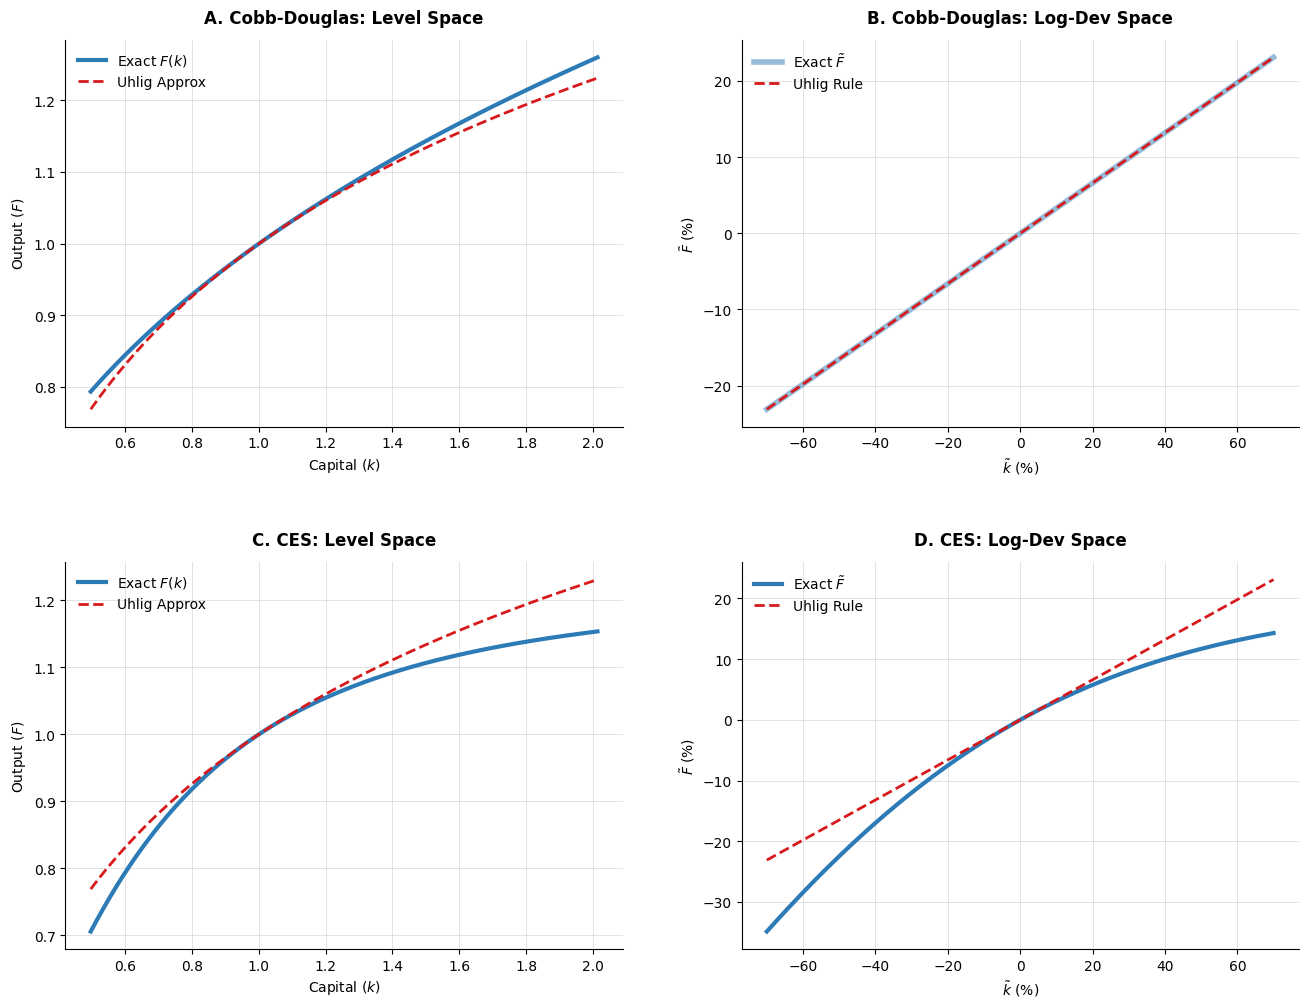

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Parameters ---
alpha = 0.33
# We use a very low rho to create high curvature for pedagogical clarity
rho_ces = -2.0  
k_ss, l_ss = 1.0, 1.0

# Steady State Values
F_ss_cd = (k_ss**alpha) * (l_ss**(1-alpha))
F_ss_ces = (alpha * k_ss**rho_ces + (1 - alpha) * l_ss**rho_ces)**(1/rho_ces)
s_k_ces = (alpha * k_ss**rho_ces) / (F_ss_ces**rho_ces)

# --- 2. Data Generation ---
# Wide range (-70% to +70%) to show the "breakdown" of the approximation
k_tilde = np.linspace(-0.7, 0.7, 300)
k_vec = k_ss * np.exp(k_tilde)

# Cobb-Douglas
F_ex_cd = (k_vec**alpha) * (l_ss**(1-alpha))
tilde_F_ex_cd = np.log(F_ex_cd / F_ss_cd)
tilde_F_approx_cd = alpha * k_tilde

# CES
F_ex_ces = (alpha * k_vec**rho_ces + (1 - alpha) * l_ss**rho_ces)**(1/rho_ces)
tilde_F_ex_ces = np.log(F_ex_ces / F_ss_ces)
tilde_F_approx_ces = s_k_ces * k_tilde

# --- 3. Plotting ---
fig, axes = plt.subplots(2, 2, figsize=(14, 11), dpi=100)
plt.rcParams.update({'font.size': 10})

def apply_style(ax, title, xlabel, ylabel):
    ax.set_title(title, fontweight='bold', fontsize=12, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, lw=0.5, alpha=0.5)
    ax.legend(frameon=False)

# ROW 1: COBB-DOUGLAS
# Levels
axes[0, 0].plot(k_vec, F_ex_cd, color="#2c7bb6", lw=3, label="Exact $F(k)$")
axes[0, 0].plot(k_vec, F_ss_cd * (1 + tilde_F_approx_cd), color="#d7191c", lw=2, ls="--", label="Uhlig Approx")
apply_style(axes[0, 0], "A. Cobb-Douglas: Level Space", "Capital ($k$)", "Output ($F$)")

# Log-Devs
axes[0, 1].plot(k_tilde*100, tilde_F_ex_cd*100, color="#2c7bb6", lw=4, label="Exact $\\tilde{F}$", alpha=0.5)
axes[0, 1].plot(k_tilde*100, tilde_F_approx_cd*100, color="#d7191c", lw=2, ls="--", label="Uhlig Rule")
apply_style(axes[0, 1], "B. Cobb-Douglas: Log-Dev Space", "$\\tilde{k}$ (%)", "$\\tilde{F}$ (%)")

# ROW 2: CES
# Levels
axes[1, 0].plot(k_vec, F_ex_ces, color="#2c7bb6", lw=3, label="Exact $F(k)$")
axes[1, 0].plot(k_vec, F_ss_ces * (1 + tilde_F_approx_ces), color="#d7191c", lw=2, ls="--", label="Uhlig Approx")
apply_style(axes[1, 0], "C. CES: Level Space", "Capital ($k$)", "Output ($F$)")

# Log-Devs
axes[1, 1].plot(k_tilde*100, tilde_F_ex_ces*100, color="#2c7bb6", lw=3, label="Exact $\\tilde{F}$")
axes[1, 1].plot(k_tilde*100, tilde_F_approx_ces*100, color="#d7191c", lw=2, ls="--", label="Uhlig Rule")
apply_style(axes[1, 1], "D. CES: Log-Dev Space", "$\\tilde{k}$ (%)", "$\\tilde{F}$ (%)")

plt.tight_layout(pad=4.0)
plt.show()

#### Consumption Euler Equation

As a more substantive economic application, consider the Euler equation from 
the Real Business Cycle model:

$$u'(C_t) = \beta\,\mathbb{E}_t\left[u'(C_{t+1})(1 + r_{t+1})\right]$$

where $u(C) = C^{1-\sigma}/(1-\sigma)$ is the CRRA utility function with 
$u'(C) = C^{-\sigma}$. Substituting:

$$C_t^{-\sigma} = \beta\,\mathbb{E}_t\left[C_{t+1}^{-\sigma}(1 + r_{t+1})\right]$$

**Step 1.** Substitute $C_t = C^* e^{\tilde{C}_t}$ and 
$r_{t+1} = r^* + \tilde{r}_{t+1}\cdot r^*$ (noting that $r$ enters additively, 
so we approximate $1 + r_{t+1} \approx (1+r^*)(1 + \frac{r^*}{1+r^*}\tilde{r}_{t+1})$):

$$(C^*)^{-\sigma}e^{-\sigma\tilde{C}_t} = \beta(C^*)^{-\sigma}
\mathbb{E}_t\left[e^{-\sigma\tilde{C}_{t+1}}(1+r^*)\left(1 + 
\frac{r^*}{1+r^*}\tilde{r}_{t+1}\right)\right]$$

**Step 2.** At the steady state $\beta(1+r^*) = 1$, so the steady-state 
terms cancel. Applying Uhlig's Rules:

$$-\sigma\tilde{C}_t \approx \mathbb{E}_t\left[-\sigma\tilde{C}_{t+1} + 
\frac{r^*}{1+r^*}\tilde{r}_{t+1}\right]$$

**Step 3.** Rearranging:

$$\boxed{\tilde{C}_t = \mathbb{E}_t[\tilde{C}_{t+1}] - 
\frac{1}{\sigma}\frac{r^*}{1+r^*}\mathbb{E}_t[\tilde{r}_{t+1}]}$$

This is the **log-linearized Euler equation**: consumption today equals expected future consumption minus $1/\sigma$ times the expected return. The coefficient $1/\sigma$ is the intertemporal elasticity of substitution — exactly the elasticity interpretation that Uhlig's method delivers automatically.

The plots below consider how an interest rate shock affects the optimal consumption path.  We plot the impulse responses for both the exact and approximate Euler equation.  

To compute an exact path, we make two simplifying assumptions:
1. Perfect Foresight: We assume the agent knows the path of interest rates $\{r_t\}_{t=0}^T$.
2. Terminal Steady State: We assume that by period $T$ (the "horizon"), the economy has returned to its steady state ($C_T = C^*$).

We rewrite the Euler equation to isolate $C_t$:

$$C_t = C_{t+1} \left[ \beta (1 + r_{t+1}) \right]^{-\frac{1}{\sigma}}$$

We then solve backward from $T-1$ to $0$. At $T$, $C_T = 1.0$ (Steady State). At $T-1$: $C_{T-1} = C_T \cdot [\beta(1+r_T)]^{-1/\sigma}$. At $T-2$: $C_{T-2} = C_{T-1} \cdot [\beta(1+r_{T-1})]^{-1/\sigma}$. This produces the non-linear path. The "error" in the log-linear model arises because the operation $\ln(\mathbb{E}[\cdot])$ is replaced with $\mathbb{E}[\ln(\cdot)]$, and the convex curvature of the power function is replaced by a flat line.

In the exact Euler equation:

$$C_t = C_{t+1} \left[ \beta (1 + r_{t+1}) \right]^{-1/\sigma}$$

In the log-linearized version:

$$\tilde{C}_t = \mathbb{E}_t[\tilde{C}_{t+1}] - \frac{1}{\sigma} \left( \frac{r^*}{1+r^*} \right) \tilde{r}_{t+1}$$

The term $\frac{1}{\sigma} \frac{r^*}{1+r^*}$ is the effective elasticity of consumption with respect to the interest rate deviation. When we use Uhlig's rule, we approximate $(1+r_{t+1})$ as $(1+r^*)(1 + \frac{r^*}{1+r^*}\tilde{r}_{t+1})$. However, the function $f(R) = R^{-1/\sigma}$ is convex. By Jensen's Inequality and the properties of linear tangents to convex curves, the linear approximation of a convex function will always lie below the actual curve. If $C_t$ is a convex function of the interest rate, a linear approximation (the red dashed line) will predict a lower level of consumption (a larger drop) than the exact curved relationship for a given increase in $r$. This explains why the log-linear IRF shows a more "aggressive" drop: the linear tangent "overshoots" the curve as the interest rate rises.

One might expect the log-linear model to be conservative, but for the RBC Euler equation, the opposite is true. Because the marginal utility of consumption is highly convex, the linear approximation of the Euler equation 'overshoots' the drop in consumption following an interest rate hike. This illustrates a critical lesson: log-linearized models tend to exaggerate the impact of shocks when the underlying economic relationships have significant curvature."

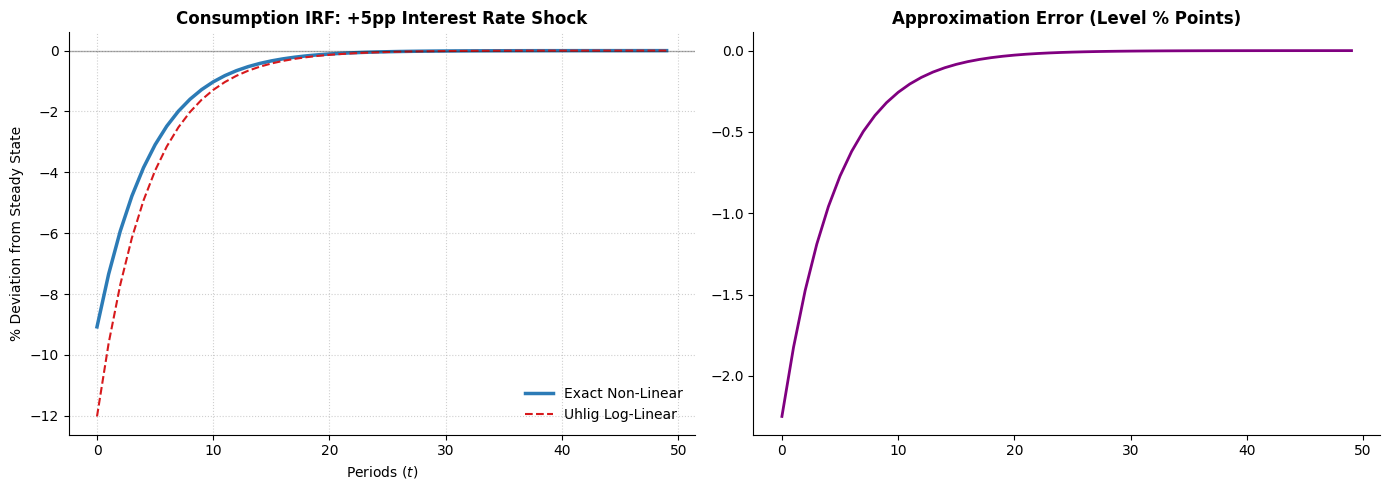

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# 1. PARAMETERS & STEADY STATE
# =============================================================================
sigma  = 2.0         # CRRA Coefficient (Curvature of Utility)
r_ss   = 0.04        # Steady-state annual interest rate
beta   = 1/(1+r_ss)  # Discount factor consistent with r_ss
rho_r  = 0.8         # Persistence of interest rate shock
shock  = 0.05        # 5 percentage point shock (Exaggerated for clarity)
T      = 50          # Simulation horizon

# =============================================================================
# 2. PATH GENERATION
# =============================================================================
t_axis = np.arange(T)

# Interest Rate Path (AR1 Process in levels)
r_path = np.zeros(T)
r_path[0] = r_ss + shock
for t in range(1, T):
    r_path[t] = r_ss + rho_r * (r_path[t-1] - r_ss)

# Log-deviation of r (used for Uhlig's Method)
r_tilde = (r_path - r_ss) / r_ss

# =============================================================================
# 3. SOLVING THE MODELS
# =============================================================================

# A. Log-Linear IRF (Uhlig's Method)
# Formula: C_tilde_t = E_t[C_tilde_t+1] - (1/sigma)*(r_ss/(1+r_ss))*r_tilde_t+1
# Integrated forward:
coeff = (1/sigma) * (r_ss / (1 + r_ss))
C_tilde = -coeff * np.cumsum(r_tilde[::-1])[::-1]

# B. Exact Non-Linear IRF (Backward Induction)
C_exact = np.ones(T) # Assume C_T = C_ss = 1
for t in reversed(range(T-1)):
    C_exact[t] = C_exact[t+1] * (beta * (1 + r_path[t+1]))**(-1/sigma)

# =============================================================================
# 4. VISUALIZATION
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=100)
plt.rcParams.update({'font.size': 10, 'font.family': 'sans-serif'})

# Panel 1: Impulse Response Functions
ax1.plot(t_axis, (C_exact - 1) * 100, color="#2c7bb6", lw=2.5, label="Exact Non-Linear")
ax1.plot(t_axis, C_tilde * 100, color="#d7191c", lw=1.5, ls="--", label="Uhlig Log-Linear")
ax1.axhline(0, color="black", lw=1, alpha=0.3)
ax1.set_title("Consumption IRF: +5pp Interest Rate Shock", fontweight='bold')
ax1.set_ylabel("% Deviation from Steady State")
ax1.set_xlabel("Periods ($t$)")
ax1.legend(frameon=False)
ax1.grid(True, linestyle=':', alpha=0.6)

# Panel 2: The Approximation Error
# (Log-Linear minus Exact)
# Convert log-deviation to level-percentage deviation for consistent comparison
C_level_approx = np.exp(C_tilde) 
error_in_pct_points = (C_level_approx - C_exact) * 100

# Visualization
ax2.plot(t_axis, error_in_pct_points, color="purple", lw=2)
ax2.set_title("Approximation Error (Level % Points)", fontweight='bold')

plt.tight_layout()
plt.show()

## Accuracy and Limitations

Log-linearization is the standard solution method in macroeconomics, but it rests on an approximation that can fail in important cases. Several limitations deserve emphasis.

**Local validity.** The approximation is accurate only in a neighborhood of the steady state. For models with large shocks — financial crises, pandemic disruptions, regime changes — the economy may move far from steady state and the linear approximation may be unreliable. As we saw in the dynamics notebook, the search and matching model is a case where nonlinearities are quantitatively important even at business cycle frequencies.

**Asymmetric dynamics.** Log-linearization produces a symmetric approximation: positive and negative shocks of equal magnitude produce responses of equal magnitude but opposite sign. Models with asymmetric nonlinearities — such as the concave matching function in the search and matching model — generate asymmetric responses that the linear approximation cannot capture. Recessions may be sharper than expansions even under symmetric shocks, a feature visible only in the nonlinear solution.

**Multiple equilibria.** If the nonlinear model has multiple steady states, the log-linearization is valid only locally around the particular steady state at which it is taken. It cannot characterize transitions between equilibria or global dynamics.

**Zero lower bound and occasionally binding constraints.** When constraints occasionally bind — the zero lower bound on interest rates, occasionally binding borrowing constraints — the linear approximation misses the kink in the equilibrium conditions at the constraint boundary. These cases require global solution methods.

Despite these limitations, log-linearization remains the dominant solution method in macroeconomics for good reason: it delivers transparent, analytically tractable solutions whose coefficients have clean economic interpretations as elasticities, and it is accurate for the small fluctuations that characterize normal business cycles. Understanding when it is appropriate — and when it is not — is an essential skill for modern macroeconomic analysis.

## Conclusion

This notebook has developed two related linearization techniques. Taylor approximation replaces a smooth nonlinear function with its tangent hyperplane at a point of interest, producing a linear map from perturbations to changes in function values. The Jacobian matrix is the multi-dimensional generalization of this idea and governs the local dynamics of macroeconomic systems around their steady states.

Log-linearization applies Taylor approximation to the logarithm of the model's equations, expressing the result in terms of percentage log-deviations from steady state. This is particularly natural for multiplicative nonlinearities and produces coefficients with elasticity interpretations. Uhlig's method provides an efficient algorithm for implementing log-linearization: substitute $x = x^*e^{\tilde{x}}$, combine exponential terms, and apply the rule $e^u \approx 1 + u$.

The worked examples — the Cobb-Douglas production function and the RBC Euler equation — illustrate that log-linearization delivers clean, interpretable results with minimal algebra. The numerical illustrations confirm that the approximation is accurate for typical business cycle fluctuations but can fail for large shocks, motivating the global solution methods discussed in the dynamics notebook.